### **[A]: Choice of a population, with supporting expenditure data**

In [4]:
!pip install -r requirements.txt

In [5]:
#Importing
%pip install python-gnupg
%pip install eep153_tools
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [11]:
#Prices
ugd4_p0 = pd.read_csv('Data Files/Uganda - Food Prices (2005-06).csv')
ugd4_p0 = ugd4_p0[ugd4_p0["u"] == "Kg"]
ugd4_p = pd.pivot_table(ugd4_p0, values="price", index=["j","u"], columns=["t","m"] , aggfunc="median")
#Food Expenditures
ugd4_x0 = pd.read_csv('Data Files/Uganda - Food Expenditures (2005-06).csv')
ugd4_x0['i'] = ugd4_x0['i'].astype(str)
ugd4_x = pd.pivot_table(ugd4_x0, values="Expenditure", index=["i","t","m"], columns="j" , aggfunc="median")
#Consumption
ugd4_x_long = ugd4_x.stack().reset_index(name="Expenditure")
ugd4_p_long = ugd4_p0
ugd4_c = ugd4_x_long.merge(ugd4_p_long, on=["j", "t", "m"], how="left")
ugd4_c["Consumption"] = ugd4_c["Expenditure"] / ugd4_c["price"]
ugd4_c = ugd4_c.pivot_table(values="Consumption", index=["i","t","m","u"], columns="j", aggfunc="sum")
#HH Characteristics
ugd_z0 = pd.read_csv('Data Files/Uganda - Household Characteristics.csv')
ugd4_z = ugd_z0[ugd_z0['t'] == '2005-06']
ugd4_z = ugd4_z.set_index(['i','t','m'])
ugd4_z.columns.name = 'k'
ugd4_z.fillna(0, inplace=True)

### **[B]: Nutritional content of different foods**

In [12]:
#FCT
ugd_fct = pd.read_csv('Data Files/Uganda - FCT.csv')
ugd_fct = ugd_fct.rename(columns={"index":"j"}).set_index(["j"])
ugd_fct.columns.name = 'n'
#RDI
ugd_rdi = pd.read_csv('Data Files/Uganda - RDA.csv')
ugd_rdi = ugd_rdi.set_index(["n"])
ugd_rdi.columns.name = 'k'

### **[A]: Estimate demand system**

In [13]:
import cfe
from cfe import Regression

ugd4_result = cfe.Regression(y=np.log(ugd4_x.stack()),d=ugd4_z)

In [14]:
ugd4_result.predicted_expenditures()

i           t        m        j                     
1013000201  2005-06  Central  Beans (dry)               1323.597218
                              Beans (fresh)             1439.061376
                              Beef                      4639.584642
                              Bread                     2865.701399
                              Cabbage (green)            633.104148
                                                           ...     
4193003510  2005-06  Western  Sugar                     2650.915669
                              Sweet Bananas             1598.694769
                              Sweet Potatoes (fresh)    6401.320991
                              Tea                        404.336078
                              Tomatoes                   793.154430
Length: 105154, dtype: float64

<Axes: xlabel='yhat', ylabel='y'>

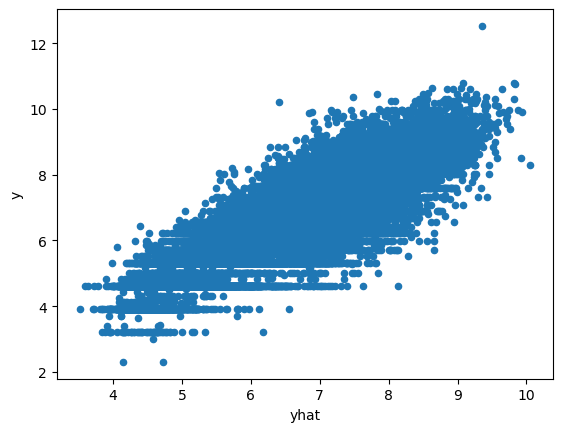

In [15]:
#Expenditures x may have duplicate columns
x1 = ugd4_x0.groupby(['i','t','m','j']).sum()
#Replace zeros with missing values
x1 = x1.replace(0,np.nan)
#Take logs of expenditures; call this y
y = np.log(x1["Expenditure"])
#Create dataframe with predicted yhat values
ugd4_acc = pd.DataFrame({'y':y,'yhat':ugd4_result.get_predicted_log_expenditures()})
#Plot yhat vs y (predicted vs actual)
ugd4_acc.plot.scatter(x='yhat',y='y')

In [16]:
ugd4_result.R2(summary=True)

np.float64(0.7480664867333393)

In [19]:
#Save result
ugd4_result.to_pickle('./Uganda05-06.rgsn')
##To access result:
#import cfe
#result = cfe.regression.read_pickle('Uganda05-06.rgsn')

### Parameters

**(Relative) Income Elasticity:** $\beta$ coefficients, which govern how *income elastic* different goods are (higher values means more elastic).  These are also called *Frisch elasticities*.
Here we use a plot to visualize, with confidence intervals.

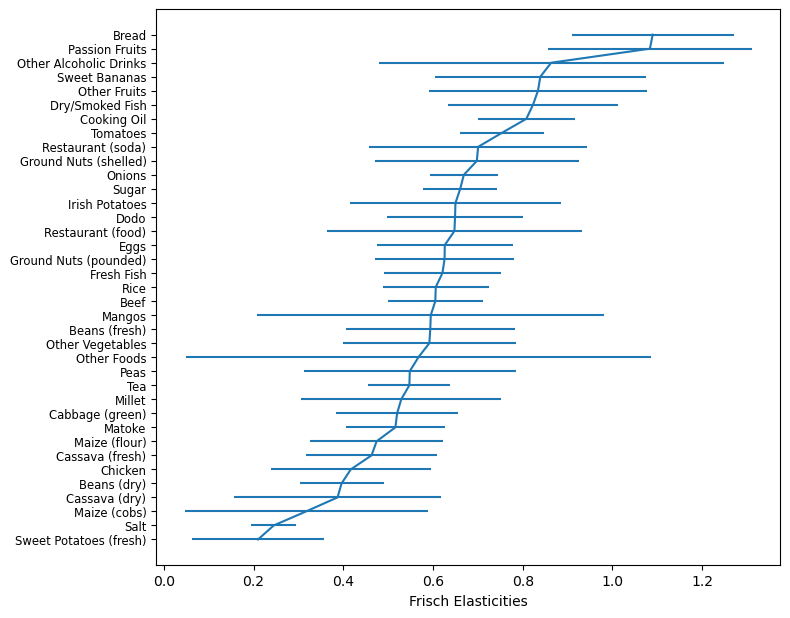

In [18]:
ax1 = ugd4_result.graph_beta()

In [22]:
ugd4_result.get_beta().sort_values(ascending=False)

j
Bread                     1.089741
Passion Fruits            1.083494
Other Alcoholic Drinks    0.863404
Sweet Bananas             0.839170
Other Fruits              0.833914
Dry/Smoked Fish           0.822870
Cooking Oil               0.808011
Tomatoes                  0.753635
Restaurant (soda)         0.700458
Ground Nuts (shelled)     0.697612
Onions                    0.668602
Sugar                     0.660511
Irish Potatoes            0.649991
Dodo                      0.649061
Restaurant (food)         0.647675
Eggs                      0.626215
Ground Nuts (pounded)     0.625641
Fresh Fish                0.620959
Rice                      0.606008
Beef                      0.605078
Mangos                    0.594964
Beans (fresh)             0.593800
Other Vegetables          0.591776
Other Foods               0.567461
Peas                      0.548102
Tea                       0.547227
Millet                    0.529116
Cabbage (green)           0.519926
Matoke            

**Demand and Household Composition:** $\gamma_j$ parameters in the regression, which capture the effects of household composition on demand

In [23]:
ugd4_result.get_gamma()

k,F 00-03,M 00-03,F 04-08,M 04-08,F 09-13,M 09-13,F 14-18,M 14-18,F 19-30,M 19-30,F 31-50,M 31-50,F 51+,M 51+,log HSize,Constant
j,,,,,,,,,,,,,,,,
Beans (dry),0.015504,0.047162,0.075536,0.057431,-0.010996,0.014517,0.019702,-0.010714,0.001039,0.075516,0.121905,0.074477,0.057461,0.085411,0.318578,7.178380
Beans (fresh),-0.012309,0.062331,0.123677,0.114357,0.100470,0.097809,0.346645,0.010315,0.034114,0.167491,0.055409,0.100271,0.222549,0.188694,0.239354,7.111754
Beef,-0.009852,0.033930,0.049713,0.056907,0.201705,0.136200,0.038495,-0.046791,-0.000525,0.081642,0.035889,0.098477,0.243036,0.265629,0.062618,8.005377
Bread,-0.021627,0.019238,0.075575,0.129155,0.211584,0.143559,-0.034082,-0.143763,0.028639,-0.032466,0.057248,0.105564,0.314192,0.121865,0.122779,6.949341
Cabbage (green),0.011088,-0.024933,0.069388,0.127768,0.065696,-0.061812,0.129050,0.046263,-0.032855,-0.029560,0.027697,0.021880,-0.050557,-0.024284,0.263563,6.276807
Cassava (dry),0.075321,0.079542,-0.120577,0.012380,-0.010455,0.168547,0.204942,0.096926,0.100486,0.018102,0.074399,0.118194,0.244272,0.137939,0.366274,7.640904
Cassava (fresh),-0.004627,0.094841,0.023199,0.089851,-0.122365,-0.015837,0.225023,0.015454,-0.045759,0.155192,0.119769,0.007501,0.105756,0.076132,0.294748,7.232809
Chicken,-0.084749,0.036516,0.032866,0.036952,0.044709,0.095149,0.009250,-0.027411,0.014182,-0.015591,0.008945,0.063235,0.091986,0.117241,-0.081049,8.362915
Cooking Oil,-0.049717,-0.026884,0.055984,0.072140,0.067569,-0.007505,-0.090188,-0.026135,-0.054300,-0.011956,0.003151,0.142215,0.097128,-0.011831,0.226952,6.355699


<Axes: ylabel='Density'>

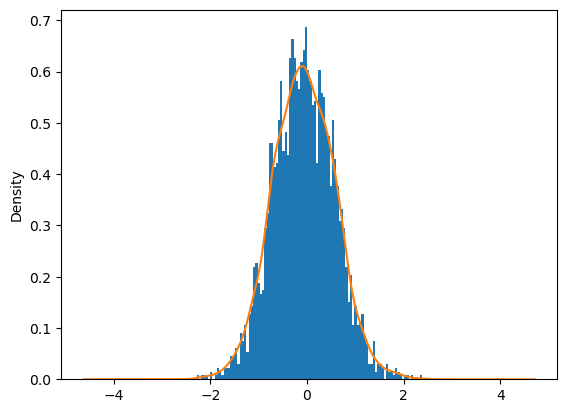

In [20]:
ax2 = ugd4_result.get_w().plot.hist(bins=100,density=True)
ugd4_result.get_w().plot.kde(ax=ax2)

### Demand and Utility

**Budgets:** Get food budget for all households, then find median budget

In [21]:
xhat = ugd4_result.predicted_expenditures()
#Total food expenditures per household
xbar = xhat.groupby(['i','t','m']).sum()
#Reference budget
xref = xbar.quantile(0.5)  # Household at 0.5 quantile is median

**Reference Prices:** Choose reference prices.  Here we chose the year 2015 and averaged prices across markets.

In [22]:
#Prices per kilogram:
pbar = ugd4_p.mean(axis=1)
pbar = pbar.reset_index(level="u", drop=True) #Reset index so that 'j' becomes a column instead of part of a MultiIndex
pbar = pbar.reindex(ugd4_result.beta.index) #Only use prices for goods we can estimate
#Replace missing prices with 1 (this is because they're best measured in expenditures)
pbar = pbar.replace(np.nan,1)
#Define a function to change a single price in the vector $p$:
def my_prices(p0,j,p=pbar):
    """
    Change price of jth good to p0, holding other prices fixed.
    """
    p = p.copy()
    p.loc[j] = p0
    return p

**Demand as a function of prices:** Demand schedules for households with different budgets

Text(0.5, 0, 'Quantities of Beef Demanded')

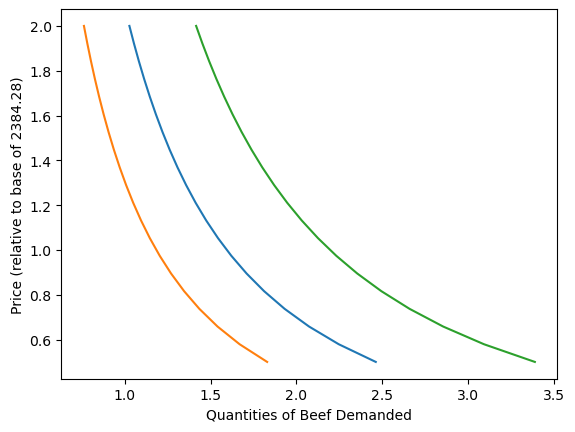

In [23]:
use = 'Beef'  #Good we want demand curve for

#Vary prices from 50% to 200% of reference.
scale = np.linspace(.5,2,20)

#Demand for Millet for household at median budget
plt.plot([ugd4_result.demands(xref,my_prices(pbar[use]*s,use,pbar))[use] for s in scale],scale)

#Demand for Millet for household at 25% percentile
plt.plot([ugd4_result.demands(xbar.quantile(0.25),my_prices(pbar[use]*s,use,pbar))[use] for s in scale],scale)

#Demand for Millet for household at 75% percentile
plt.plot([ugd4_result.demands(xbar.quantile(0.75),my_prices(pbar[use]*s,use,pbar))[use] for s in scale],scale)

plt.ylabel(f"Price (relative to base of {pbar[use]:.2f})")
plt.xlabel(f"Quantities of {use} Demanded")

**Engel Curves:** Tracing how demand changes with budget

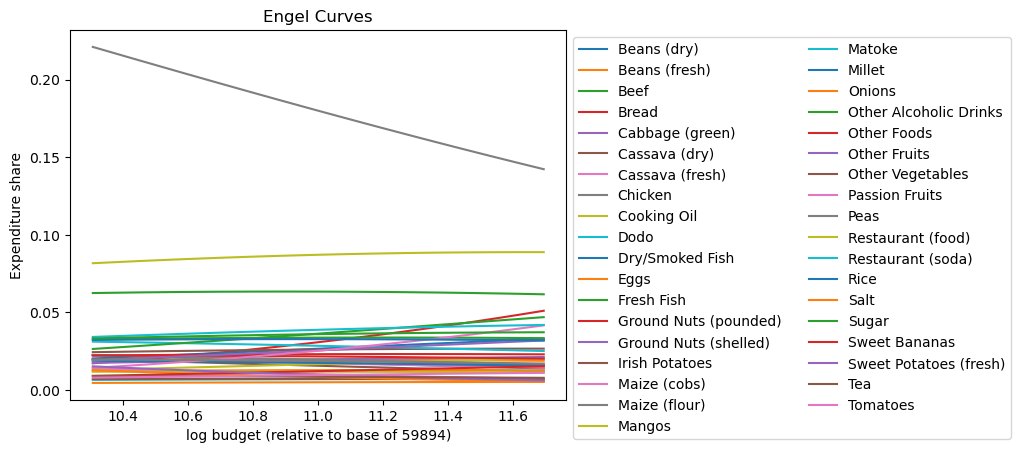

In [24]:
fig,ax = plt.subplots()

ax.plot(np.log(scale*xref),[ugd4_result.expenditures(s*xref,pbar)/(s*xref) for s in scale])
ax.set_xlabel(f'log budget (relative to base of {xref:.0f})')
ax.set_ylabel(f'Expenditure share')
ax.set_title('Engel Curves')
ax.legend(ugd4_result.expenditures(xref,pbar).index.tolist(), loc="upper left", bbox_to_anchor=(1, 1), ncol=2)

**Indirect Utility Function:**

Text(0.5, 1.0, 'Indirect Utility Function')

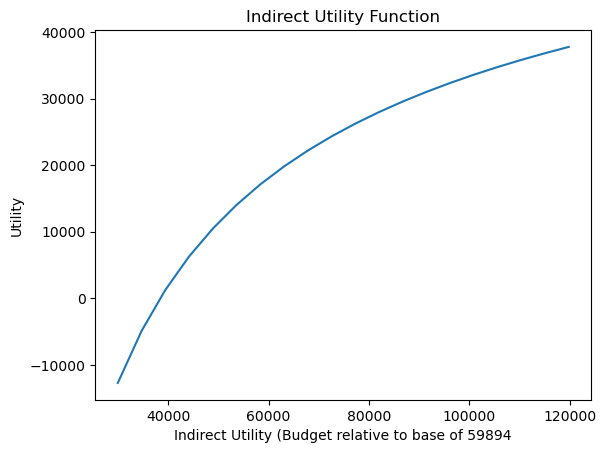

In [25]:
fig,ax = plt.subplots()

ax.plot(scale*xref,[ugd4_result.indirect_utility(s*xref,pbar) for s in scale])
ax.set_xlabel(f'Indirect Utility (Budget relative to base of {xref:.0f}')
ax.set_ylabel(f'Utility')
ax.set_title('Indirect Utility Function')

### **[B]: Nutritional adequacy of diet**

In [26]:
#Get result saved above
ugd4_result = cfe.read_pickle('Uganda05-06.rgsn')
#Quantities in kg: expenditures divided by prices/kg
qhat = (xhat.unstack('j')/ugd4_p.reset_index(drop=True, level="u").transpose()).dropna(how='all')
#Drop missing columns
qhat = qhat.loc[:,qhat.count()>0]

In [27]:
#Columns of qhat to match fct
use = ugd_fct.index.intersection(qhat.columns)

nutrients = qhat[use]@ugd_fct.loc[use,:]
nutrients.mean()    # NB: Nutrients are for past /week/ for entire household

n
Energy          183022.755174
Protein           6617.726495
Fiber             3615.586280
Folate           52313.247051
Calcium          31709.092333
Carbohydrate     33168.659309
Iron              1255.528485
Niacin            1652.236500
Riboflavin         103.207431
Thiamin            150.392583
Vitamin A        34371.929125
Vitamin B-12       260.570466
Vitamin B-6        305.145884
Vitamin C        15324.728183
Zinc               674.734051
Magnesium            0.000000
Phosphorus           0.000000
Potassium            4.024058
Vitamin E            0.000000
Vitamin K            0.000000
dtype: float64

In [28]:
#Obtain recommended daily intake
ugd4_z = ugd4_z[ugd_rdi.columns.tolist()]
hh_rdi = ugd4_z@ugd_rdi.T
#Make this a recommended WEEKLY intake
hh_rwi = hh_rdi*7
# Match up nutrient names
use_nutrients = nutrients.columns.intersection(hh_rwi.columns)
nutrient_ratio = (nutrients[use_nutrients]/hh_rwi[use_nutrients]).dropna()
#Display
nutrient_ratio

,,n,Energy,Protein,Fiber,Folate,Calcium,Carbohydrate,Iron,Niacin,Riboflavin,Thiamin,Vitamin A,Vitamin B-12,Vitamin B-6,Vitamin C,Zinc,Magnesium,Phosphorus,Potassium,Vitamin E,Vitamin K
i,t,m,,,,,,,,,,,,,,,,,,,,
1013000201,2005-06,Central,10.762197,26.254255,13.329403,17.762919,2.810666,22.328048,16.598010,17.788086,13.654028,15.017151,4.981067,25.948651,29.526178,27.473679,9.167090,0.0,0.0,0.000085,0.0,0.0
1013000209,2005-06,Central,9.667321,15.568346,11.531574,10.389850,2.291373,17.932975,12.956453,11.769412,8.713104,9.966668,3.371008,16.075748,15.323503,12.451113,7.346285,0.0,0.0,0.000073,0.0,0.0
1013000210,2005-06,Central,2.846654,5.101542,3.538099,3.867095,0.673571,5.733352,3.522938,3.563902,2.847712,3.612639,1.229537,4.861741,6.460946,5.426983,2.267725,0.0,0.0,0.000028,0.0,0.0
1013000211,2005-06,Central,7.209081,18.430130,8.723274,11.198677,1.709580,10.997859,8.368796,11.107569,8.412761,9.341560,3.308566,17.060590,19.120454,19.327530,6.402416,0.0,0.0,0.000057,0.0,0.0
1013000212,2005-06,Central,3.673065,7.106238,4.493917,4.796063,0.828588,6.362330,4.440323,4.731198,3.757147,4.501112,1.589098,6.692839,7.973692,7.066153,3.081303,0.0,0.0,0.000033,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4193003506,2005-06,Western,1.630360,2.843803,2.684328,3.587776,0.482923,3.891304,2.382725,1.914790,1.549305,2.886124,0.887041,1.904137,4.667462,3.754118,1.434984,0.0,0.0,0.000014,0.0,0.0
4193003507,2005-06,Western,6.041864,13.374147,9.926396,13.060641,1.868755,12.987668,9.134106,9.348163,7.433446,10.202346,3.142757,10.425593,19.387031,17.985024,5.547741,0.0,0.0,0.000041,0.0,0.0
4193003508,2005-06,Western,3.706080,6.885929,6.247885,7.303400,1.097055,8.496750,4.250690,5.038605,4.140274,6.401843,2.144499,4.233539,11.483211,9.330301,3.477653,0.0,0.0,0.000028,0.0,0.0


In [30]:
#Save df
nutrient_ratio.to_csv('Nutrient Data/05-06 Nutrient Data.csv')

<Axes: >

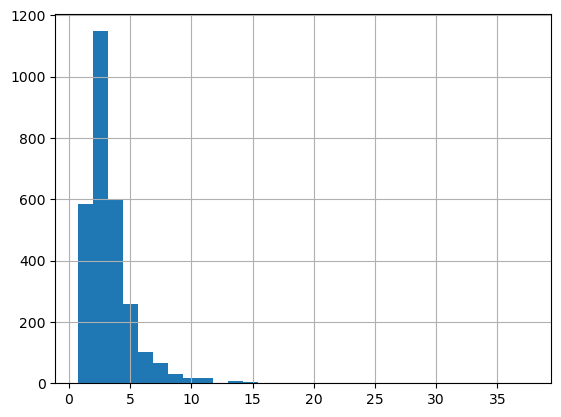

In [31]:
#Plot nutrient ratio for specific nutrient
%matplotlib inline
nutrient_ratio['Energy'].hist(bins=30)